# Emergence and stability of depth reponses

Analysis of depth responses in neurons at day 1 to 5

In [33]:
from v1_depth_map.revisions.revision_sessions import sessions
sphere_sessions = [(k,v) for k,v in sessions.items() if 'sphere' in v]
mice = set([sess[0].split('_')[0] for sess in sphere_sessions])

In [34]:
import numpy as np
import roicat.util
import warnings

def get_tracked_roi(roicat_path):
    """
    Extracts a mapping of ROI indices across sessions for tracked neurons.

    Args:
        roicat_path (str): Path to the ROICaT results_all.richfile.zip.

    Returns:
        np.ndarray: A 2D array of shape (n_clusters, n_sessions) containing
            local ROI indices. Each row is a neuron, each column is a session.
            NaN means the neuron was not tracked that day.
    """
    
    # Load results while suppressing version warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Field 'versions_supported' is empty")
        results = roicat.util.RichFile_ROICaT(path=roicat_path).load()
        
    labels_bySession = results['clusters']['labels_bySession']
    n_sessions = len(labels_bySession)
    
    # Get unique cluster labels excluding -1
    all_labels = np.concatenate(labels_bySession)
    unique_labels = np.unique(all_labels)
    unique_labels = unique_labels[unique_labels != -1]
    n_clusters = len(unique_labels)
    
    # Initialize the output array with NaN
    tracked_rois = np.full((n_clusters, n_sessions), np.nan)
    
    # Fill the array using vectorized session-wise mapping
    for s_idx, session_labels in enumerate(labels_bySession):
        session_labels = np.array(session_labels)
        mask = session_labels != -1
        # Map ROI indices to their corresponding cluster label rows
        tracked_rois[session_labels[mask], s_idx] = np.where(mask)[0]
                
    return tracked_rois

In [45]:
# Load all neurons_df
import flexiznam as flz
import pandas as pd

project = 'colasa_3d-vision_revisions'

neurons_dfs = dict()
for sess_name, protocol in sphere_sessions:
    mouse, sess = sess_name.split('_')
    neurons_df = pd.read_pickle(flz.get_processed_path(project) / mouse / sess / 'neurons_df.pickle')
    neurons_df['mouse'] = mouse
    neurons_df['session'] = sess_name
    neurons_df['uid'] = neurons_df.session.astype(str) + '_' + neurons_df.roi.astype(str)
    neurons_df['day'] = int(protocol.split('_')[1])
    neurons_dfs[sess_name] =neurons_df
neurons_df = pd.concat(neurons_dfs.values(), ignore_index=True)
print(f'Loaded {len(neurons_df)} neurons from {len(neurons_df.session.unique())} sessions')


Loaded 12439 neurons from 20 sessions


In [46]:
# Add depth tuned boolean
neurons_df["depth_tuned"] = neurons_df.apply(
    lambda x: x["depth_tuning_test_spearmanr_rval_closedloop"] > 0.1
    and x["depth_tuning_test_spearmanr_pval_closedloop"] < 0.05,
    axis=1,
)

PZAG16.3b
PZAG16.3c
PZAG17.3a
PZAH17.1e


Text(0, 0.5, 'Proportion depth tuned')

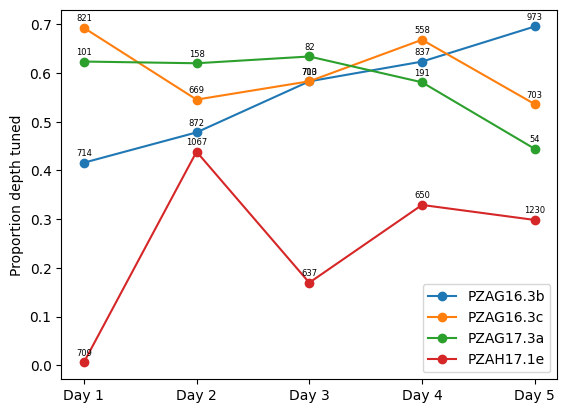

In [55]:
import matplotlib.pyplot as plt
from cottage_analysis.plotting import depth_selectivity_plots
fontsize_dict = {"title": 7, "label": 7, "tick": 5, "legend": 5}

ax = plt.subplot(1,1,1)
for mouse, mouse_df in neurons_df.groupby('mouse'):
    print(mouse)
    frac = np.zeros(5)
    for day, day_df in mouse_df.groupby('day'):
        valid = day_df[~np.isnan(day_df.depth_tuned)]
        frac[day-1] = (valid.depth_tuned.sum()/len(valid.depth_tuned))
        ax.text(day-1, frac[day-1]+0.01, len(valid.depth_tuned), fontsize=6, horizontalalignment='center', verticalalignment='bottom')
    ax.plot(np.arange(5), frac, 'o-', label=mouse)
ax.legend(loc='lower right')
ax.set_xticks(np.arange(5), labels=[f'Day {i}' for i in range(1,6)])
ax.set_ylabel('Proportion depth tuned')

In [56]:
ndf = neurons_df[(neurons_df.mouse =='PZAH17.1e')&(neurons_df.day == 1)]
ndf.shape

(709, 131)

In [60]:
ndf.session

11730    PZAH17.1e_S20250304
11731    PZAH17.1e_S20250304
11732    PZAH17.1e_S20250304
11733    PZAH17.1e_S20250304
11734    PZAH17.1e_S20250304
                ...         
12434    PZAH17.1e_S20250304
12435    PZAH17.1e_S20250304
12436    PZAH17.1e_S20250304
12437    PZAH17.1e_S20250304
12438    PZAH17.1e_S20250304
Name: session, Length: 709, dtype: object

In [59]:
(ndf.depth_tuning_test_spearmanr_rval_closedloop > 0.1).sum()

np.int64(56)

{'paths_stat': ['/nemo/lab/znamenskiyp/home/shared/projects/colasa_3d-vision_revisions/PZAG16.3c/S20250219/suite2p_rois_annotated_0/plane0/stat.npy',
  '/nemo/lab/znamenskiyp/home/shared/projects/colasa_3d-vision_revisions/PZAG16.3c/S20250220/suite2p_rois_annotated_0/plane0/stat.npy',
  '/nemo/lab/znamenskiyp/home/shared/projects/colasa_3d-vision_revisions/PZAG16.3c/S20250310/suite2p_rois_annotated_0/plane0/stat.npy',
  '/nemo/lab/znamenskiyp/home/shared/projects/colasa_3d-vision_revisions/PZAG16.3c/S20250313/suite2p_rois_annotated_0/plane0/stat.npy'],
 'paths_ops': ['/nemo/lab/znamenskiyp/home/shared/projects/colasa_3d-vision_revisions/PZAG16.3c/S20250219/suite2p_rois_annotated_0/plane0/ops.npy',
  '/nemo/lab/znamenskiyp/home/shared/projects/colasa_3d-vision_revisions/PZAG16.3c/S20250220/suite2p_rois_annotated_0/plane0/ops.npy',
  '/nemo/lab/znamenskiyp/home/shared/projects/colasa_3d-vision_revisions/PZAG16.3c/S20250310/suite2p_rois_annotated_0/plane0/ops.npy',
  '/nemo/lab/znamenskiy

In [75]:
import roicat.util
root_path = '/Volumes/lab-znamenskiyp/home/shared/projects/colasa_3d-vision_revisions'
neurons_df['tracking_id'] = np.nan
for mouse in mice:
    sessions = sphere_sessions
    roicat_path='/'.join([root_path, mouse, 'ROICat_spheretubes', 
        f"{mouse}_roicat.tracking.results_all.richfile.zip"])
    
    # Load results while suppressing version warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Field 'versions_supported' is empty")
        results = roicat.util.RichFile_ROICaT(path=roicat_path).load()
        
    labels_bySession = results['clusters']['labels_bySession']
    for sess_id, values in enumerate(labels_bySession):
        sess = results['input_data']['paths_stat'][sess_id]
        sess_name = '_'.join(sess.split(project)[1][1:].split('/')[:2])
        mask = (neurons_df.session==sess_name)
        neurons_df.loc[neurons_df.session==sess_name, 'tracking_id'] = values

neurons_df['tracking_uid'] = neurons_df.mouse + neurons_df.tracking_id.astype(str)

In [106]:
tracked_neurons = neurons_df[neurons_df['tracking_id'] != -1]
tracking_ids = tracked_neurons.tracking_uid.unique()

depth_tuning = np.zeros((len(tracking_ids), 5), float)+ np.nan
is_depth_tuned = np.zeros((len(tracking_ids), 5), float)+ np.nan
for itrack, tid in enumerate(tracking_ids):
    ndf = neurons_df[neurons_df.tracking_uid==tid]
    for day, depth, is_tuned in zip(ndf.day, ndf.preferred_depth_closedloop, ndf.depth_tuned):
        depth_tuning[itrack, day-1] = depth
        is_depth_tuned[itrack, day-1] = is_tuned
    

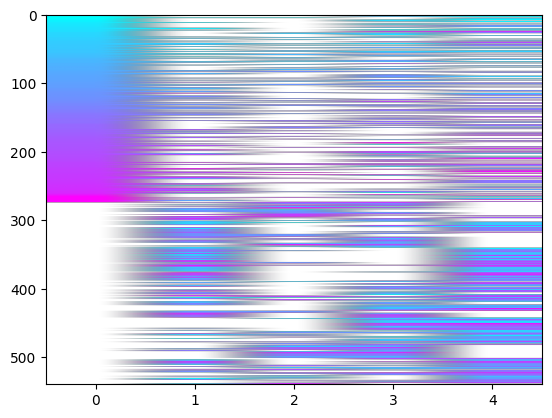

In [113]:
valid = np.all(np.nan_to_num(is_depth_tuned, nan=1)==1, axis=1)

d =depth_tuning[valid,:]
plt.imshow(np.log(d[np.argsort(d[:,0]),:]), aspect='auto', cmap='cool')

In [ ]:
import numpy as np

(~np.isnan(tracked_rois)).sum(axis=0)

array([400, 197, 291, 357])